In [1]:
import pandas as pd
import os
from glob import glob
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
from features import features

path="/home/wei/research/data/2025/01/14/1RF/lag_window=8/"
input_folder = "/home/wei/research/data/input_folder"
# 挑选出3天pam的值
output_hysteresis = path+"滞后特征"
output_abnormal = path+"异常值编码"
final_file_path = path+"final.csv"
filtered_file_path = path+"final0.7.csv"
# 主循环中传递滞后窗口大小
lag_window = 8  # 可以灵活调整滞后窗口大小

# 1. 创建滞后特征 ==========

In [2]:
features = features  # 假设您有这些特征

input_files = glob(os.path.join(input_folder, "*.csv"))
all_data = []

os.makedirs(output_hysteresis, exist_ok=True)

def extract_lagged_features(df, required_columns, lag_window):
    rows = []
    for i in range(lag_window, len(df)):  # 使用动态窗口大小
        pam_t = df.loc[i, "pam"]
        if i + 1 >= len(df):
            break

        pam_t_plus_1 = df.loc[i + 1, "pam"]

        if pd.isna(pam_t) or pd.isna(pam_t_plus_1):
            continue

        # 提取 t-lag_window 到 t 的特征
        lagged_features = [df.loc[i - j, required_columns] for j in range(lag_window, -1, -1)]
        rolling_window = pd.DataFrame(lagged_features)

        # 计算统计特征
        rolling_mean = rolling_window.mean()
        rolling_std = rolling_window.std()
        rolling_skew = rolling_window.skew()
        # rolling_max = rolling_window.max()
        # rolling_min = rolling_window.min()

        target = pam_t_plus_1 - pam_t
        row = (list(rolling_window.values.flatten())
            + rolling_mean.tolist()               # 均值
            + rolling_std.tolist()                # 标准差
            + rolling_skew.tolist()               # 偏度
            # + rolling_max.tolist()                # 最大值
            # + rolling_min.tolist()                # 最小值
            + [target]                            # 目标值
         )
        rows.append(row)
    return rows


for file in input_files:
    df = pd.read_csv(file)
    required_columns = [col for col in features if col in df.columns]

    rows = extract_lagged_features(df, required_columns, lag_window)

    if rows:
        output_df = pd.DataFrame(
            rows,
            columns=[
                f"{col}_t-{i}" for i in range(lag_window, -1, -1) for col in required_columns
            ] + [f"{col}_mean" for col in required_columns]
              + [f"{col}_std" for col in required_columns]
              + [f"{col}_skew" for col in required_columns]
              # + [f"{col}_max" for col in required_columns]
              # + [f"{col}_min" for col in required_columns]
              + ["target"]
        )
        output_file = os.path.join(output_hysteresis, os.path.basename(file))
        output_df.to_csv(output_file, index=False)
        all_data.append(output_df)


# 2. 异常值编码 ==========

In [3]:
input_folder = output_hysteresis
os.makedirs(output_abnormal, exist_ok=True)

input_files = glob(os.path.join(input_folder, "*.csv"))

for file in input_files:
    data = pd.read_csv(file)
    data.fillna(-1, inplace=True)  # 用 -1RF 填充缺失值
    encoded_columns = {}

    isolation_forest = IsolationForest(contamination=0.05, random_state=42)#IsolationForest 不支持数据中存在 NaN 值，因此需要在调用 fit_predict 前对数据进行处理，
    anomaly_scores = isolation_forest.fit_predict(data.drop(columns=['target']))
    data['anomaly'] = anomaly_scores


    for column in data.columns:
        if column == "target":
            continue

        if pd.api.types.is_numeric_dtype(data[column]):
            Q1 = data[column].quantile(0.25)
            Q3 = data[column].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            encoded_columns[f"{column}_encoded"] = data[column].apply(
                lambda x: 0 if x < lower_bound else (2 if x > upper_bound else 1)
            )

    encoded_data = pd.DataFrame(encoded_columns)
    final_data = pd.concat([data, encoded_data], axis=1)
    final_file_path = os.path.join(output_abnormal, os.path.basename(file))
    final_data.to_csv(final_file_path, index=False)


# 3. 合成 Final 文件 ==========

In [4]:
directory_path = output_abnormal


final_df = pd.DataFrame()
for file_name in os.listdir(directory_path):
    if file_name.endswith(".csv"):
        file_path = os.path.join(directory_path, file_name)
        df = pd.read_csv(file_path)
        final_df = pd.concat([final_df, df], ignore_index=True)

final_df.to_csv(final_file_path, index=False)


# 4. 筛选缺失值 ==========

In [5]:
sensor_data = pd.read_csv(final_file_path)
missing_percentage = sensor_data.isnull().mean() * 100
selected_columns = missing_percentage[missing_percentage <= 30].index.tolist()
filtered_data = sensor_data[selected_columns]
filtered_data.to_csv(filtered_file_path, index=False)


# 5. 数据增强与训练 ==========

In [6]:
data = pd.read_csv(filtered_file_path)
sensor_columns = [col for col in data.columns if col not in ['target']]
data[sensor_columns] = data[sensor_columns].apply(pd.to_numeric, errors='coerce')
data[sensor_columns] = data[sensor_columns].fillna(data[sensor_columns].mean())

# 标准化
scaler = StandardScaler()
scaled_features = scaler.fit_transform(data[sensor_columns])
X = pd.DataFrame(scaled_features, columns=sensor_columns)
y = data['target']

In [7]:
from collections import Counter
from imblearn.over_sampling import ADASYN, SMOTE
import numpy as np

# 计算每个类别的样本数
class_counts = Counter(y)

# 定义采样策略：对所有类别增加 1.5 倍
sampling_strategy = {label: int(class_counts[label] * 1.5) for label in class_counts}

# 动态调整 ADASYN 的 n_neighbors
n_neighbors_adasyn = max(1, min(3, min(class_counts.values()) - 1))

# 使用 ADASYN 对非多数类进行采样
adasyn = ADASYN(
    sampling_strategy='not majority',
    n_neighbors=n_neighbors_adasyn,
    random_state=42
)
X_resampled, y_resampled = adasyn.fit_resample(X, y)

# 对极端值单独处理
extreme_samples = np.abs(y) > (y.mean() + 2 * y.std())

if np.any(extreme_samples):  # 检查是否存在极端样本
    X_extreme, y_extreme = X[extreme_samples], y[extreme_samples]

    # 检查 y_extreme 是否包含多于一个类别
    unique_classes = np.unique(y_extreme)
    if len(unique_classes) > 1:
        # 定义极端值的采样策略
        extreme_sampling_strategy = {
            label: max(2, len(X_extreme[y_extreme == label])) * 2
            for label in unique_classes
        }

        for label, num_samples in extreme_sampling_strategy.items():
            # 获取当前类别的索引
            current_class_indices = (y_extreme == label)
            current_class_count = np.sum(current_class_indices)

            # 检查当前类别的样本数量是否足够
            if current_class_count < 2:
                print(f"Skipping label {label} due to insufficient samples.")
                continue

            # 动态调整 SMOTE 的 n_neighbors
            n_neighbors_smote = max(1, min(3, current_class_count - 1))

            # 对当前类别应用 SMOTE
            smote_extreme = SMOTE(
                sampling_strategy={label: num_samples},
                random_state=42,
                k_neighbors=n_neighbors_smote
            )
            try:
                X_class_resampled, y_class_resampled = smote_extreme.fit_resample(
                    X_extreme[current_class_indices],
                    y_extreme[current_class_indices]
                )

                # 合并增强后的数据
                X_resampled = np.vstack([X_resampled, X_class_resampled])
                y_resampled = np.hstack([y_resampled, y_class_resampled])
            except ValueError as e:
                print(f"Skipping label {label} due to SMOTE error: {e}")
    else:
        print("Extreme samples contain only one class, skipping augmentation.")
else:
    print("No extreme samples found, skipping extreme sample augmentation.")

# 输出增强后的数据形状
print("Resampled X shape:", X_resampled.shape)
print("Resampled y shape:", y_resampled.shape)


Skipping label -15.0 due to SMOTE error: The target 'y' needs to have more than 1 class. Got 1 class instead
Skipping label -14.0 due to SMOTE error: The target 'y' needs to have more than 1 class. Got 1 class instead
Skipping label -13.0 due to SMOTE error: The target 'y' needs to have more than 1 class. Got 1 class instead
Skipping label -12.0 due to SMOTE error: The target 'y' needs to have more than 1 class. Got 1 class instead
Skipping label -11.0 due to SMOTE error: The target 'y' needs to have more than 1 class. Got 1 class instead
Skipping label 11.0 due to SMOTE error: The target 'y' needs to have more than 1 class. Got 1 class instead
Skipping label 12.0 due to SMOTE error: The target 'y' needs to have more than 1 class. Got 1 class instead
Skipping label 13.0 due to SMOTE error: The target 'y' needs to have more than 1 class. Got 1 class instead
Skipping label 14.0 due to SMOTE error: The target 'y' needs to have more than 1 class. Got 1 class instead
Skipping label 15.0 due

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=200, random_state=42)

In [9]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

# 6. 评估与可视化 ==========


In [10]:
y_pred = rf_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"\n测试集上的均方误差（MSE）：{mse}")

# 极端值样本评估
threshold = 2.0
errors = np.abs(y_pred - y_test)
correct_predictions = errors <= threshold

extreme_samples = (np.abs(y_test) > 10)
extreme_mse = mean_squared_error(y_test[extreme_samples], y_pred[extreme_samples])

print(f"\n误差在 {threshold} 范围内的准确率：{np.mean(correct_predictions) * 100:.2f}%")
print(f"极端值样本的MSE：{extreme_mse}")



测试集上的均方误差（MSE）：4.197517307692308

误差在 2.0 范围内的准确率：77.27%
极端值样本的MSE：2.601065379403794


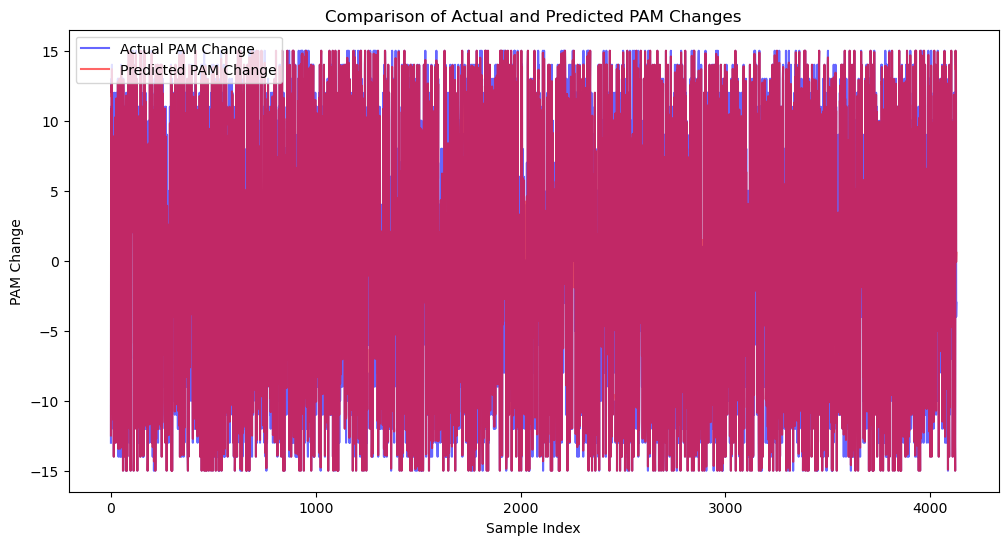

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, label="Actual PAM Change", color="blue", alpha=0.6)
plt.plot(y_pred, label="Predicted PAM Change", color="red", alpha=0.6)
plt.legend()
plt.title("Comparison of Actual and Predicted PAM Changes")
plt.xlabel("Sample Index")
plt.ylabel("PAM Change")
plt.show()
